# You can run sapphire interactively in 3 simple steps:
1. import sapphire
2. define python dictionary of input parameters (see docs and below) 
3. sapphire.run(parameters) 

Soon there will be:
- a way to run from the command line "python -m sapphire parameters.json"-
- repeatedly run internally with built-in HMC/nested sampling functions
- the JAX version ported over for JIT (10x speed boost) and gradients (for both optimization and physical interpretation)

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from timeit import default_timer as timer
import pandas as pd
from astropy.table import Table
from astropy.cosmology import Planck15
from astropy import units as u
s_to_yr = u.s.to('yr')

import sys
sys.path.append('/mnt/home/bterrazas/ceph/sapphire')
import sapphire 

In [2]:
""" This is an optional feature we are using to downsample the # of halos we will model to speed up computation time """

# define a list of (Mlow,Mhigh,N) tuples with same bin definitions as Behroozi+19 relation
# we will only model N random halos within each of these z=0 Mvir mass bins to cut down on modeling time
# this list of tuples is an input runtime parameter for sapphire below (along with np.random.seed(#) for reproducibility) 
downsample_bins = np.arange(10.0,14.2,0.2) # note the masses are log10 mvir
# downsample_bins = np.arange(10.0,14.5,0.5)
print(downsample_bins)

# we will ask for 5 random halos per mass bin
n = 5
downsample_defs = [(downsample_bins[i],downsample_bins[i+1],n) for i in range(len(downsample_bins)-1)]

downsample_defs

[10.  10.2 10.4 10.6 10.8 11.  11.2 11.4 11.6 11.8 12.  12.2 12.4 12.6
 12.8 13.  13.2 13.4 13.6 13.8 14. ]


[(10.0, 10.2, 5),
 (10.2, 10.399999999999999, 5),
 (10.399999999999999, 10.599999999999998, 5),
 (10.599999999999998, 10.799999999999997, 5),
 (10.799999999999997, 10.999999999999996, 5),
 (10.999999999999996, 11.199999999999996, 5),
 (11.199999999999996, 11.399999999999995, 5),
 (11.399999999999995, 11.599999999999994, 5),
 (11.599999999999994, 11.799999999999994, 5),
 (11.799999999999994, 11.999999999999993, 5),
 (11.999999999999993, 12.199999999999992, 5),
 (12.199999999999992, 12.399999999999991, 5),
 (12.399999999999991, 12.59999999999999, 5),
 (12.59999999999999, 12.79999999999999, 5),
 (12.79999999999999, 12.99999999999999, 5),
 (12.99999999999999, 13.199999999999989, 5),
 (13.199999999999989, 13.399999999999988, 5),
 (13.399999999999988, 13.599999999999987, 5),
 (13.599999999999987, 13.799999999999986, 5),
 (13.799999999999986, 13.999999999999986, 5)]

In [3]:
# set up a general parameters dict 

# try running new thermal_general model on same 656 TNG trees 
parameters = {'output_path':'/mnt/home/bterrazas/ceph/sapphire/output/', # path where any output files should be saved (irrelevant if return_or_write=='return' below)
              
              ### runtime-related related parameters (you only need to vary tree_path) 
              
              'tree_type':'tng_sapphire', # type of merger trees / MAHs -- this determines what read_trees module gets loaded
              'tree_path':'/mnt/home/bterrazas/ceph/sapphire/data/tng_trees_compactified_20subvolumes.npz', # either a directory containing tree files or path to single tree file itself 
              'halo_names':[], # optional for certain simulations -- list of halo names/IDs to process (default=empty=process all trees for given tree_type and tree_dir)
              'subvolumes':None, # for testing speed purposes, only work with trees from a single TNG subvolume 
              'num_readers':5, # irrelevant for tree_type='tng_sapphire'
              'num_writers':5, # irrelevant when return_or_write = 'return' (otherwise how many output writer tasks to start in parallel)
              'return_or_write':'return', # if 'return', return pandas dataframe (you should assign to a variable below); if 'write' then save dataframe to hdf5
              'min_root_mass':1e10, # relevant for tree_type ='tng' and 'tng_sapphire', not 'fire2' or 'fire2_pandya22'
              'max_root_mass':None, # relevant for tree_type=tng_sapphire -- halos above this z=0 Mvir will not be modeled (set to None or 0 to model everything)
              'downsample_defs':downsample_defs, # list of tuples (logMlow,logMhigh,N) such that N random halos will be chosen in each mass bin (None otherwise)
              'downsample_seed':999, # np.random.seed(#) to ensure reproducibility when downsampling to N random halos in each mass bin (None otherwise)
              'rtol':1e-5, # relative error tolerance for ODE solver (this controls error on exponent of state variables), should be 1e-3 or lower 
              'atol':1e-3, # absolute error tolerance for ODE solver (this controls early evolution when ICs close to 0), should be 1e-3 or lower 
              
              ### fixed physical model parameters (this just sets the overall physical model and associated fixed parameters) 
              
              'physical_model':'thermal_general', # name of physical model (and associated free parameter functional forms)
              'coolfunc':'wiersma09', # which cooling function to use (wiersma09, sd93, ploeckinger20)
              'alpha_n':-3/2., # slope of CGM density power law
              'alpha_T':0.0, # slope of CGM temperature power law 
              'tau_escape':1.0, # scales the halo outflow timescale tdyn=tau*Rvir/Vvir
              'f_recycle':0.4, # instantaneous stellar-->ISM recycling fraction 
              'e_wind_halo':1.0, # specific energy of halo wind relative to Ecgm/Mcgm                            
              'yZ':0.02, # metal yield of 1 SN per 100 Msun of stars formed (2 Msun / 100 Msun = 0.02 for 10 Msun of SN ejecta)
              'return_all':False, # whether to return only the ODE RHS for solver, or all properties at each time for outputting
              
              ### FREE PARAMETERS BELOW THIS LINE -- WE WILL VARY A SUBSET OF THESE 
              ### there are 4 physical parameters: mass, energy and metal loading factors, and the ISM depletion time
              ### each physical parameter has 4 hyperparameters describing a power law: normalization, slope, and the redshift dependences of those two
              ### the exact power law is X(Vvir,z) = A * (Vvir/125.)**(alpha0 + alphaz*(1+z)) * (1+z)**beta              
              
              'etaM_A':0.1, # normalization of power law for mass loading factor [prior range: 0.01 to 100]
              'etaM_alpha0':-0.5, # slope of power law for mass loading factor [prior range: -2 to 2]
              'etaM_alphaz':0.0, # this can be fixed to 0; redshift dependence of slope of power law for mass loading factor [prior range: -2 to 2]
              'etaM_beta':0.0, # this can be fixed to 0; redshift dependence of normalization of power law for mass loading factor [prior range: -2 to 2]
              'tdep_A':3.0, # [prior range: 0.01 to 10]
              'tdep_alpha0':-3.0, # [prior range: -2 to 2]
              'tdep_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'tdep_beta':-0.7, # [prior range: -2 to 2]
              'etaE_A':0.5, # [prior range: 0.01 to 1]
              'etaE_alpha0':-0.5, # [prior range: -2 to 2]
              'etaE_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'etaE_beta':0.0,   # this can be fixed to 0 [prior range: -2 to 2]
              'etaZ_A':0.5, # [prior range: 0.01 to 1]
              'etaZ_alpha0':0.0, # [prior range: -2 to 2]
              'etaZ_alphaz':0.0, # this can be fixed to 0 [prior range: -2 to 2]
              'etaZ_beta':0.0} # this can be fixed to 0 [prior range: -2 to 2]


In [4]:
tstart = timer()
df_results = sapphire.run(parameters) # this is the only line you need, I just enclosed it in a timer for benchmarking
print('Finished in %s sec'%(timer()-tstart))


Finished in 44.57886088901432 sec


In [5]:
### the results are returned as a pandas dataframe 
# the row index is roothaloid and the columns are different physical properties 
# the entries are the time series of these physical properties for each halo 
df_results.columns

Index(['t_accrete', 'tdyn_ism', 'Mdot_in_halo', 'M_ism', 'redshift',
       'MZdot_star', 'T0', 'M_star', 'Tvir', 'cosmic_age', 'Eth_cgm',
       'MZdot_wind', 'Mdot_out_halo', 'M_bh', 'MZdot_yield', 'Zin_halo',
       'MZdot_in_halo', 'Vvir', 'Mdot_sfr', 'Edot_out_halo', 'Mdot_ism',
       'MZdot_sfr', 'tdep_ism', 'tcool_eff', 'Rvir', 'MZ_cgm', 'NFW_c',
       'NFW_vcirc', 'tdyn_halo', 'Ebind_cgm', 'etaZ_ism', 'MZdot_cgm',
       'Mdot_bh', 'log_Zcgm', 'Edot_in_halo', 'MZdot_cool', 'Mfilt',
       'Edot_cgm_th', 'M_cgm', 'Mvir', 'Edot_cool', 'MZdot_ism', 'Zism',
       'etaM_ism', 'f_UV', 'etaE_ism', 'f_prev', 'Mdot_wind', 'tff_eff',
       'Delta_Ecgm', 'Ncoolingshells', 'Mdot_in_dm', 'Zcgm', 'n0', 'evir_halo',
       'Mdot_cool', 'MZdot_out_halo', 'MZ_star', 'Edot_wind', 'Mdot_cgm',
       'MZ_ism', 'sol_nfev', 'sol_njev', 'sol_nlu', 'sol_success',
       'sol_status'],
      dtype='object')

In [6]:
# np.array([df_results.iloc[irow]['M_bh'][-1] for irow in range(len(df_results))])

In [7]:
# suppose the only thing we cared about was predicting the z=0 SMHM relation for a given set of model parameters

# use list comprehension to store final z=0 Mvir and Mstar of each halo (i.e., of each row aka roothaloid of df_filtered)
# here we are iterating over each row which is a distinct roothaloid
# the values of every column for a given row/roothaloid are numpy arrays of time series of that property going from high-z to z~0

z0_Mvir = np.array([df_results.iloc[irow]['Mvir'][-1] for irow in range(len(df_results))])
z0_Mstar = np.array([df_results.iloc[irow]['M_star'][-1] for irow in range(len(df_results))])
z0_Mbh = np.array([df_results.iloc[irow]['M_bh'][-1] for irow in range(len(df_results))])
z0_Mdotbh = np.array([df_results.iloc[irow]['Mdot_bh'][-1] for irow in range(len(df_results))])
z0_Mdot_cgm = np.array([df_results.iloc[irow]['Mdot_cgm'][-1] for irow in range(len(df_results))])
z0_Mdot_ism = np.array([df_results.iloc[irow]['Mdot_ism'][-1] for irow in range(len(df_results))])

z0_M_ism = np.array([df_results.iloc[irow]['M_ism'][-1] for irow in range(len(df_results))])

Text(0, 0.5, '$\\log_{10}M_{\\rm star}/M_{\\rm vir}$ (z=0)')

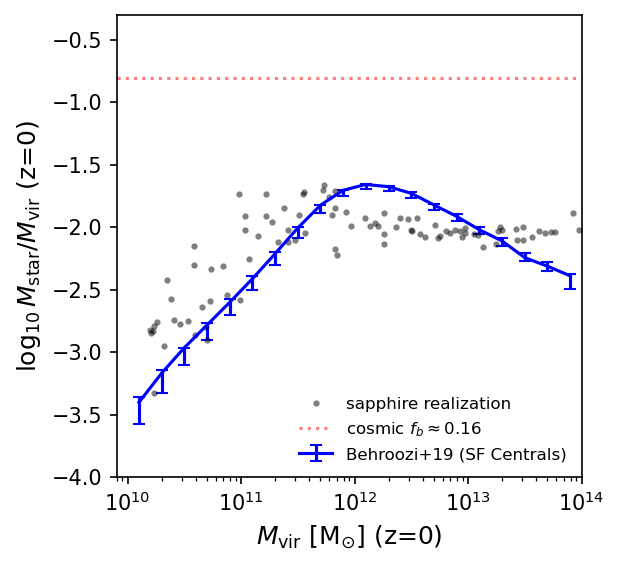

In [8]:
# overplot the z=0 SMHM relation of this model vs the Behroozi SMHM relation for centrals at z=0

fig, ax = plt.subplots(1,figsize=(4,4),dpi=150)

### plot Behroozi+19 relation including only central SF galaxies/halos
# first read in Behroozi+19 UniverseMachine DR1 Median SMHM relation at z=0  
# and discard bins below logmvir<10.5 due to Bolshoi-Planck resolution limit (not sure why he included these)
tum = Table.read('smhm_a1.002312.dat',format='ascii')
tum = tum[(tum['HM(0)']>=10.0) & (tum['HM(0)']<=14.0)]

ax.errorbar(10**tum['HM(0)'],tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')

# plot our model's realization
ax.plot(z0_Mvir,np.log10(z0_Mstar/z0_Mvir),'k.',alpha=0.5,mec='none',label='sapphire realization')

ax.set_xscale('log')
ax.set_xlim(None,1e14)
ax.set_ylim(-4,-0.3)

ax.axhline(np.log10(Planck15.Ob0/Planck15.Om0),color='r',ls=':',alpha=0.5,label=r'cosmic $f_b\approx0.16$')

ax.legend(loc='lower right',fontsize=8,fancybox=True,framealpha=0)

ax.set_xlabel(r'$M_{\rm vir}$ [M$_{\odot}$] (z=0)',fontsize=12)
ax.set_ylabel(r'$\log_{10}M_{\rm star}/M_{\rm vir}$ (z=0)',fontsize=12)


#### You can see that since we don't have AGN yet, the model overpredicts the SMHM relation in massive group/cluster halos
#### Other observable constraints can also be folded in

Text(0, 0.5, 'Mdot_BH [Msun/yr]')

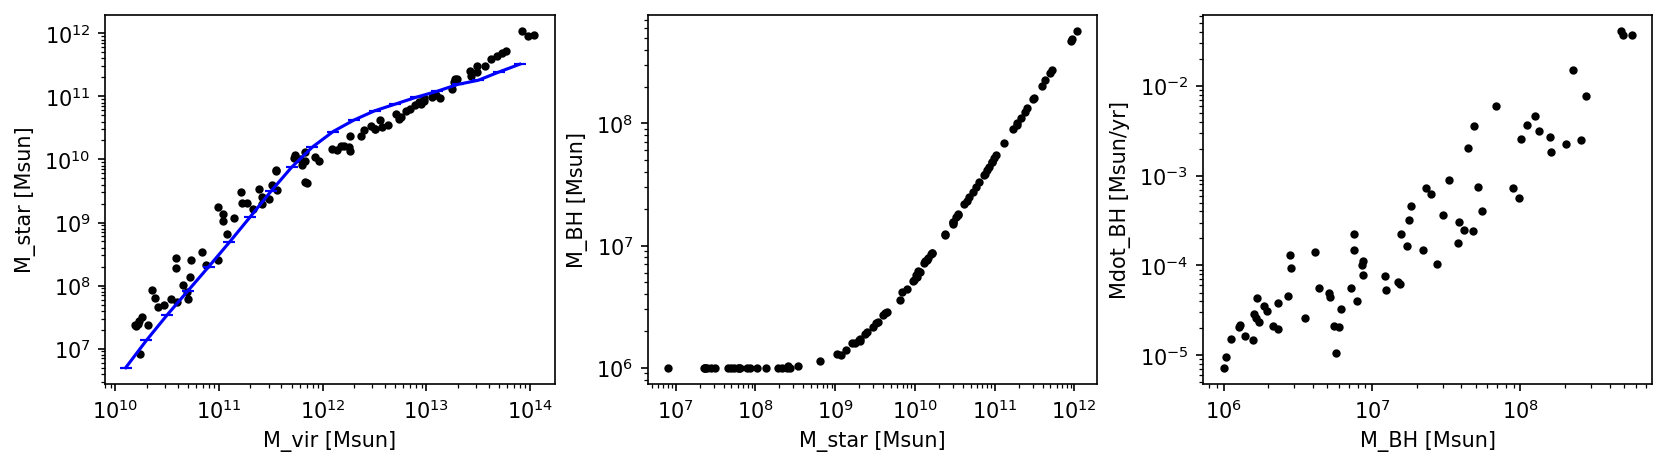

In [9]:
fig, axes = plt.subplots(nrows=1,ncols=3,figsize=(11,3),dpi=150,constrained_layout=True)

axes[0].loglog(z0_Mvir,z0_Mstar,'k.')
axes[0].errorbar(10**tum['HM(0)'],10**tum['HM(0)']*10**tum['Med_Cen_SF(7)'],yerr=[np.abs(tum['Err-(9)']),np.abs(tum['Err+(8)'])],fmt='b-',capsize=3,label='Behroozi+19 (SF Centrals)')
axes[0].set_xlabel('M_vir [Msun]')
axes[0].set_ylabel('M_star [Msun]')

axes[1].loglog(z0_Mstar,z0_Mbh,'k.')
axes[1].set_xlabel('M_star [Msun]')
axes[1].set_ylabel('M_BH [Msun]')

axes[2].loglog(z0_Mbh,z0_Mdotbh,'k.')
axes[2].set_xlabel('M_BH [Msun]')
axes[2].set_ylabel('Mdot_BH [Msun/yr]')

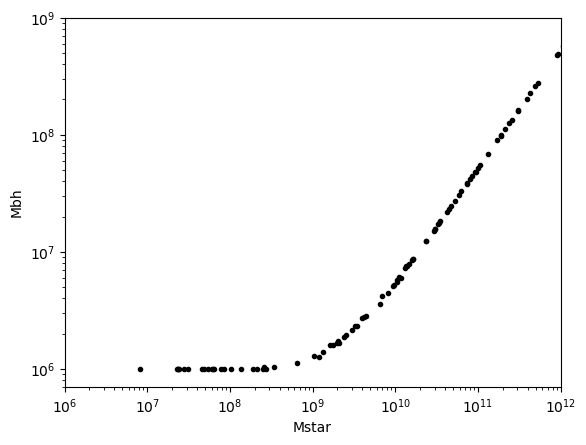

In [10]:
plt.figure()

plt.loglog(z0_Mstar, z0_Mbh, 'k.')

plt.xlim(1e6, 1e12)
plt.ylim(7e5, 1e9)
plt.xlabel('Mstar')
plt.ylabel('Mbh')
plt.show()

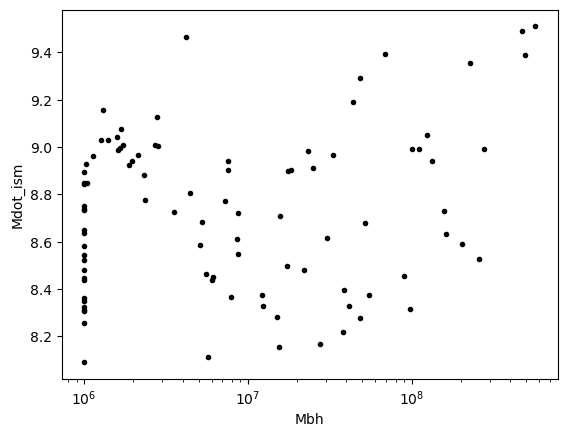

In [11]:
plt.figure()

plt.semilogx(z0_Mbh, np.log10(z0_M_ism), 'k.')

# plt.xlim(1e6, 1e12)
# plt.ylim(7e5, 1e9)
plt.xlabel('Mbh')
plt.ylabel('Mdot_ism')
plt.show()

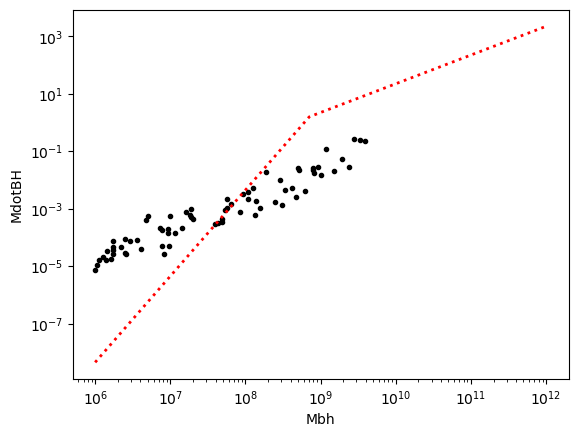

In [21]:
from astropy import constants as const
from astropy import units as u
c = const.c.to('cm/s').value
yr_to_s = u.yr.to('s') # if you multiply something in yr by this, you get it in units of sec
Msun_to_g = u.Msun.to('g') 

plt.figure()

plt.loglog(z0_Mbh, z0_Mdotbh, 'k.')

Mbh_array = np.logspace(6, 12, 100)
Chi0 = 0.002
Mpiv = 10**8
Beta = 2
ChiMax = 0.1

def Chi(chi0, mpiv, beta, chimax):
    chi = np.zeros(len(Mbh_array))
    for i in range(len(Mbh_array)):
        chi[i] = min((chi0 * (Mbh_array[i] / mpiv)**beta), chimax)
    return chi

Ledd = 1.26e38 * Mbh_array                 # erg/s, m_BH in Msun
# eddington mass accretion rate of BHs
eta = 0.1
mdotedd = (Ledd / (eta * c**2)) * (yr_to_s/Msun_to_g)        # Msun/yr

plt.loglog(Mbh_array, Chi(Chi0, Mpiv, Beta, ChiMax)*mdotedd, c='r', ls=':', lw=2)

plt.xlabel('Mbh')
plt.ylabel('MdotBH')
plt.show()

In [ ]:

def Rfree(b,tau,vw,Lagn):
    c = 299792             # km/s
    Beta = vw/c
    mp = 1.6726e-24        # grams
    rho0 = 4e-24           # g/cm**3
    mu = 0.6
    n0 = rho0/(mu * mp)    # cm**-3
    Rfree = 10. * (Beta/0.1)**(-1) * (tau/b)**(0.5) * (Lagn/1e45)**(0.5) * (n0)**(-0.5)

    return Rfree
    
    
b = 1
tau = 6
vw = 10e3              # km/s
Lagn = 1e44            # erg/s

print('bola_10_10', Rfree(1,6,10e3,1e44))
print('bola_10_5', Rfree(1,12,5e3,1e44))
print('bola_1_10', Rfree(1,1,10e3,1e44))
print('bola_1_5', Rfree(1,2,5e3,1e44))

Rfree(1,6,10e3,1e47)

# c = 299792             # km/s
# Beta = vw/c
# mp = 1.6726e-24        # grams
# rho0 = 4e-24           # g/cm**3
# mu = 0.6
# n0 = rho0/(mu * mp)    # cm**-3

# Rfree = 10. * (Beta/0.1)**(-1) * (tau/b)**(0.5) * (Lagn/1e45)**(0.5) * (n0)**(-0.5)
# print(Rfree, 'pc')